**DBSCAN**

In [1]:
!pip install umap-learn skrebate matplotlib-venn openpyxl -q

  Preparing metadata (setup.py) ... done


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.preprocessing        import MinMaxScaler
from sklearn.neighbors            import KNeighborsClassifier
from sklearn.metrics              import silhouette_score, davies_bouldin_score
from sklearn.cluster              import DBSCAN
from sklearn.model_selection      import train_test_split
from sklearn.feature_selection    import mutual_info_classif, chi2

import umap
from scipy.spatial.distance       import cdist
from skrebate                     import ReliefF
from matplotlib_venn              import venn2
from sklearn.neighbors import NearestNeighbors

Fs58: (886, 58)  |  Fs35: (886, 35)

DBSCAN internal metrics:
Feature set  eps (auto)  Clusters  Noise pts  Silhouette up  Davies-Bouldin dn  Dunn Index up
       Fs58      0.1207         3        351         0.6621             1.2940           0.25
       Fs35      0.0857         3        343         0.5550             1.1222           0.20

── Quality scores (train) ──
  Q(Fs58) = 0.8738  dif(0)=0.1125  dif(1)=0.1398
  Q(Fs35) = 0.8921  dif(0)=0.0760  dif(1)=0.1398
  DeltaQ = +0.0182

── Quality scores (test) ──
  Q(Fs58) = 0.8894  dif(0)=0.0843  dif(1)=0.1368
  Q(Fs35) = 0.9067  dif(0)=0.0602  dif(1)=0.1263
  DeltaQ = +0.0173


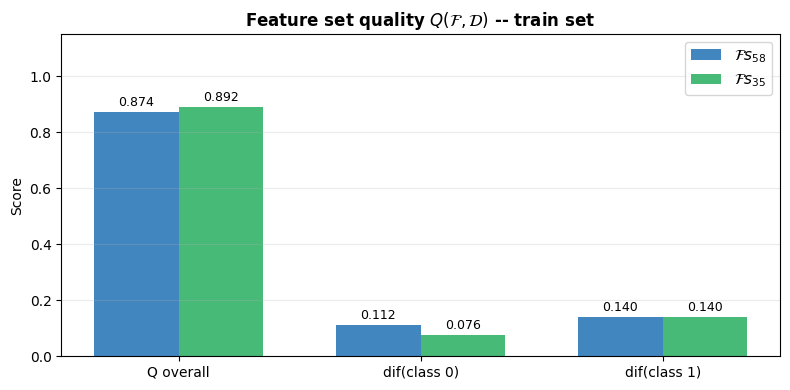


Done.


In [4]:
BASE_DIR    = '/content'
FIGURES_DIR = os.path.join(BASE_DIR, 'Figures')
RESULTS_DIR = os.path.join(BASE_DIR, 'Results')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
df = pd.read_excel("/content/dataset.xlsx", engine="openpyxl")
y  = df["label"].astype(int)
X  = df.drop(columns=["Unnamed: 0", "row", "label"], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

FINAL_FEATURES = pd.read_csv('/content/FINAL_35_features_selected.csv')['feature'].tolist()

X58 = X.values
X35 = X[FINAL_FEATURES].values
print(f"Fs58: {X58.shape}  |  Fs35: {X35.shape}")

def dunn_index(X, labels):
    unique = np.unique(labels[labels != -1])
    if len(unique) < 2:
        return np.nan
    inter, intra = [], []
    for i, ci in enumerate(unique):
        for cj in unique[i+1:]:
            inter.append(cdist(X[labels == ci], X[labels == cj],metric='hamming').min())
        pts = X[labels == ci]
        if len(pts) > 1:
            intra.append(cdist(pts, pts,metric='hamming').max())
    return min(inter) / max(intra) if intra else np.nan

results = []
for name, X_in in [('Fs58', X58), ('Fs35', X35)]:
    dists, _ = NearestNeighbors(n_neighbors=5, metric='hamming').fit(X_in).kneighbors(X_in)
    eps_auto = np.median(dists[:, -1])

    labels     = DBSCAN(eps=eps_auto, min_samples=5, metric='hamming').fit(X_in).labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()

    mask = labels != -1
    if mask.sum() > 1 and n_clusters >= 2:
        sil = silhouette_score(X_in[mask], labels[mask], metric='hamming')
        dbi = davies_bouldin_score(X_in[mask], labels[mask])
        dnn = dunn_index(X_in[mask], labels[mask])
    else:
        sil = dbi = dnn = np.nan

    results.append({
        'Feature set':       name,
        'eps (auto)':        round(eps_auto, 4),
        'Clusters':          n_clusters,
        'Noise pts':         n_noise,
        'Silhouette up':     round(sil, 4) if not np.isnan(sil) else 'n/a',
        'Davies-Bouldin dn': round(dbi, 4) if not np.isnan(dbi) else 'n/a',
        'Dunn Index up':     round(dnn, 4) if not np.isnan(dnn) else 'n/a',
    })

metrics_df = pd.DataFrame(results)
print("\nDBSCAN internal metrics:")
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'UL_01_dbscan_metrics.csv'), index=False)


def compute_Q(X_arr, y_arr):
    """
    dif(c) = fraction of class-c patients whose 1-NN has the opposite label.
    Q = 1 - mean(dif(0), dif(1))
    """
    nn = KNeighborsClassifier(n_neighbors=2, metric='hamming').fit(X_arr, y_arr)
    difs = {}
    for c in [0, 1]:
        idx       = np.where(y_arr == c)[0]
        neighbors = nn.kneighbors(X_arr[idx], n_neighbors=2, return_distance=False)[:, 1]
        difs[c]   = np.mean(y_arr[neighbors] != c)
    return 1 - np.mean(list(difs.values())), difs

for split_name, X_full, X_sel, y_split in [
    ('train', X_train.values, X_train[FINAL_FEATURES].values, y_train.values),
    ('test',  X_test.values,  X_test[FINAL_FEATURES].values,  y_test.values),
]:
    Q58, difs58 = compute_Q(X_full, y_split)
    Q35, difs35 = compute_Q(X_sel,  y_split)
    print(f"\n── Quality scores ({split_name}) ──")
    print(f"  Q(Fs58) = {Q58:.4f}  dif(0)={difs58[0]:.4f}  dif(1)={difs58[1]:.4f}")
    print(f"  Q(Fs35) = {Q35:.4f}  dif(0)={difs35[0]:.4f}  dif(1)={difs35[1]:.4f}")
    print(f"  DeltaQ = {Q35 - Q58:+.4f}")

Q58_tr, difs58_tr = compute_Q(X_train.values, y_train.values)
Q35_tr, difs35_tr = compute_Q(X_train[FINAL_FEATURES].values, y_train.values)

cats = ['Q overall', 'dif(class 0)', 'dif(class 1)']
v58  = [Q58_tr, difs58_tr[0], difs58_tr[1]]
v35  = [Q35_tr, difs35_tr[0], difs35_tr[1]]
x, w = np.arange(3), 0.35

fig, ax = plt.subplots(figsize=(8, 4))
b58 = ax.bar(x - w/2, v58, w, label=r'$\mathcal{F}s_{58}$', color='#2171B5', alpha=0.85)
b35 = ax.bar(x + w/2, v35, w, label=r'$\mathcal{F}s_{35}$', color='#27AE60', alpha=0.85)
ax.bar_label(b58, fmt='%.3f', fontsize=9, padding=2)
ax.bar_label(b35, fmt='%.3f', fontsize=9, padding=2)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title(r'Feature set quality $Q(\mathcal{F}, \mathcal{D})$ -- train set', fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'UL_02_quality_scores.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nDone.")


GOLDSTEIN VS OURS

Fs35: (886, 35)  |  Goldstein24: (886, 24)

DBSCAN internal metrics:
Feature set  eps (auto)  Clusters  Noise pts  Silhouette up  Davies-Bouldin dn  Dunn Index up
       Fs35      0.0857         3        343         0.5550             1.1222         0.2000
Goldstein24      0.0833         3        254         0.3529             1.1686         0.1333

── Quality scores (train) ──
  Q(Fs35)        = 0.8921  dif(0)=0.0760  dif(1)=0.1398
  Q(Goldstein24) = 0.8726  dif(0)=0.1520  dif(1)=0.1029
  DeltaQ = -0.0195

── Quality scores (test) ──
  Q(Fs35)        = 0.9067  dif(0)=0.0602  dif(1)=0.1263
  Q(Goldstein24) = 0.8781  dif(0)=0.0964  dif(1)=0.1474
  DeltaQ = -0.0286


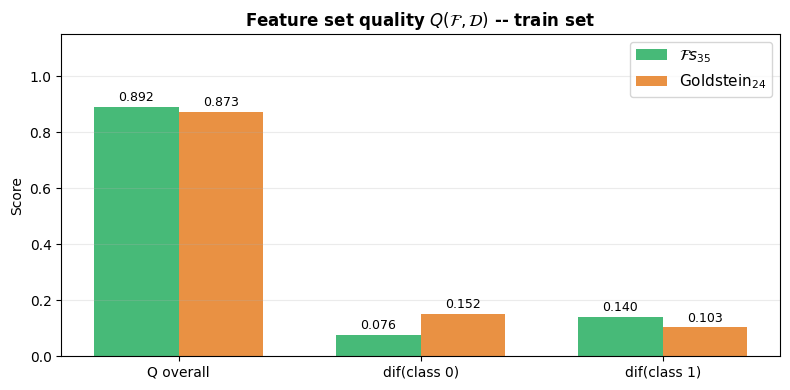


Done.


In [6]:
BASE_DIR    = '/content'
FIGURES_DIR = os.path.join(BASE_DIR, 'Figures')
RESULTS_DIR = os.path.join(BASE_DIR, 'Results')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

df = pd.read_excel("/content/dataset.xlsx", engine="openpyxl")
y  = df["label"].astype(int)
X  = df.drop(columns=["Unnamed: 0", "row", "label"], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
FINAL_FEATURES    = pd.read_csv('/content/FINAL_35_features_selected.csv')['feature'].tolist()
GOLDSTEIN_FEATURES = pd.read_csv('/content/24_Goldstein_features.csv').iloc[:, 0].tolist()
X35  = X[FINAL_FEATURES].values
X24  = X[GOLDSTEIN_FEATURES].values
print(f"Fs35: {X35.shape}  |  Goldstein24: {X24.shape}")

def dunn_index(X, labels):
    unique = np.unique(labels[labels != -1])
    if len(unique) < 2:
        return np.nan
    inter, intra = [], []
    for i, ci in enumerate(unique):
        for cj in unique[i+1:]:
            inter.append(cdist(X[labels == ci], X[labels == cj], metric='hamming').min())
        pts = X[labels == ci]
        if len(pts) > 1:
            intra.append(cdist(pts, pts, metric='hamming').max())
    return min(inter) / max(intra) if intra else np.nan

results = []
for name, X_in in [('Fs35', X35), ('Goldstein24', X24)]:
    dists, _ = NearestNeighbors(n_neighbors=5, metric='hamming').fit(X_in).kneighbors(X_in)
    eps_auto = np.median(dists[:, -1])

    labels     = DBSCAN(eps=eps_auto, min_samples=5,metric='hamming').fit(X_in).labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()

    mask = labels != -1
    if mask.sum() > 1 and n_clusters >= 2:
        sil = silhouette_score(X_in[mask], labels[mask], metric='hamming')
        dbi = davies_bouldin_score(X_in[mask], labels[mask])
        dnn = dunn_index(X_in[mask], labels[mask])
    else:
        sil = dbi = dnn = np.nan

    results.append({
        'Feature set':       name,
        'eps (auto)':        round(eps_auto, 4),
        'Clusters':          n_clusters,
        'Noise pts':         n_noise,
        'Silhouette up':     round(sil, 4) if not np.isnan(sil) else 'n/a',
        'Davies-Bouldin dn': round(dbi, 4) if not np.isnan(dbi) else 'n/a',
        'Dunn Index up':     round(dnn, 4) if not np.isnan(dnn) else 'n/a',
    })

metrics_df = pd.DataFrame(results)
print("\nDBSCAN internal metrics:")
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'UL_01_dbscan_metrics_35vs24.csv'), index=False)

def compute_Q(X_arr, y_arr):
    """
    dif(c) = fraction of class-c patients whose 1-NN has the opposite label.
    Q = 1 - mean(dif(0), dif(1))
    """
    nn = KNeighborsClassifier(n_neighbors=2,metric='hamming').fit(X_arr, y_arr)
    difs = {}
    for c in [0, 1]:
        idx       = np.where(y_arr == c)[0]
        neighbors = nn.kneighbors(X_arr[idx], n_neighbors=2, return_distance=False)[:, 1]
        difs[c]   = np.mean(y_arr[neighbors] != c)
    return 1 - np.mean(list(difs.values())), difs

for split_name, X_full, X_sel, y_split in [
    ('train', X_train[FINAL_FEATURES].values, X_train[GOLDSTEIN_FEATURES].values, y_train.values),
    ('test',  X_test[FINAL_FEATURES].values,  X_test[GOLDSTEIN_FEATURES].values,  y_test.values),
]:
    Q35, difs35 = compute_Q(X_full, y_split)
    Q24, difs24 = compute_Q(X_sel,  y_split)
    print(f"\n── Quality scores ({split_name}) ──")
    print(f"  Q(Fs35)        = {Q35:.4f}  dif(0)={difs35[0]:.4f}  dif(1)={difs35[1]:.4f}")
    print(f"  Q(Goldstein24) = {Q24:.4f}  dif(0)={difs24[0]:.4f}  dif(1)={difs24[1]:.4f}")
    print(f"  DeltaQ = {Q24 - Q35:+.4f}")

Q35_tr, difs35_tr = compute_Q(X_train[FINAL_FEATURES].values, y_train.values)
Q24_tr, difs24_tr = compute_Q(X_train[GOLDSTEIN_FEATURES].values, y_train.values)

cats = ['Q overall', 'dif(class 0)', 'dif(class 1)']
v35  = [Q35_tr, difs35_tr[0], difs35_tr[1]]
v24  = [Q24_tr, difs24_tr[0], difs24_tr[1]]
x, w = np.arange(3), 0.35

fig, ax = plt.subplots(figsize=(8, 4))
b35 = ax.bar(x - w/2, v35, w, label=r'$\mathcal{F}s_{35}$',       color='#27AE60', alpha=0.85)
b24 = ax.bar(x + w/2, v24, w, label=r'Goldstein$_{24}$',           color='#E67E22', alpha=0.85)
ax.bar_label(b35, fmt='%.3f', fontsize=9, padding=2)
ax.bar_label(b24, fmt='%.3f', fontsize=9, padding=2)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title(r'Feature set quality $Q(\mathcal{F}, \mathcal{D})$ -- train set', fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'UL_02_quality_scores_35vs24.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nDone.")
